<a href="https://colab.research.google.com/github/Peihan-Cui/CS175-AI-vs-Human-Code-Detection/blob/main/175_Basic_Data_Analysis_For_Project_Proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the 'language' column from the combined "AI-Human-Generated-Program-Code-Dataset(2).csv" and "AI-Human-Generated-Program-Code-Dataset(1).csv" datasets, specifically filtering for 'Python' entries, and then perform elementary data analysis such as counting Python entries and identifying unique values in relevant columns.

## Load Data

### Subtask:
Load the 'AI-Human-Generated-Program-Code-Dataset(2).csv' and 'AI-Human-Generated-Program-Code-Dataset(1).csv' files into pandas DataFrames.


**Reasoning**:
Load the two CSV files into pandas DataFrames and display their first few rows to verify successful loading.



In [ ]:
import pandas as pd

df1 = pd.read_csv('/content/AI-Human-Generated-Program-Code-Dataset(2).csv')
df2 = pd.read_csv('/content/AI-Human-Generated-Program-Code-Dataset(1).csv')

print("First few rows of df1:")
print(df1.head())
print("\nFirst few rows of df2:")
print(df2.head())

First few rows of df1:
   id  problem_number language difficulty   generator_name     generator_type  \
0  91               1     Java       easy  InstructCodeT5+  HuggingFace Model   
1  92               1   Python       easy  InstructCodeT5+  HuggingFace Model   
2  93               1      C++       easy  InstructCodeT5+  HuggingFace Model   
3  94               2     Java       easy  InstructCodeT5+  HuggingFace Model   
4  95               2   Python       easy  InstructCodeT5+  HuggingFace Model   

                                         description  \
0  You are given a 0-indexed integer array nums. ...   
1  You are given a 0-indexed integer array nums. ...   
2  You are given a 0-indexed integer array nums. ...   
3  Your laptop keyboard is faulty, and whenever y...   
4  Your laptop keyboard is faulty, and whenever y...   

                                              prompt  \
0  prompt = """\nYou are given a 0-indexed intege...   
1  prompt = """\nYou are given a 0-indexe

## Combine Data

### Subtask:
Combine the two loaded DataFrames into a single DataFrame.


**Reasoning**:
To combine the two DataFrames (`df1` and `df2`) into a single DataFrame (`combined_df`), I will use `pd.concat`. It's important to ignore the original indices to avoid duplicates and potential issues. After combining, I will display the first few rows and the shape of the new DataFrame to confirm the operation was successful and to verify its dimensions.



In [ ]:
combined_df = pd.concat([df1, df2], ignore_index=True)

print("First few rows of combined_df:")
print(combined_df.head())

print("\nShape of combined_df:")
print(combined_df.shape)

First few rows of combined_df:
   id  problem_number language difficulty   generator_name     generator_type  \
0  91               1     Java       easy  InstructCodeT5+  HuggingFace Model   
1  92               1   Python       easy  InstructCodeT5+  HuggingFace Model   
2  93               1      C++       easy  InstructCodeT5+  HuggingFace Model   
3  94               2     Java       easy  InstructCodeT5+  HuggingFace Model   
4  95               2   Python       easy  InstructCodeT5+  HuggingFace Model   

                                         description  \
0  You are given a 0-indexed integer array nums. ...   
1  You are given a 0-indexed integer array nums. ...   
2  You are given a 0-indexed integer array nums. ...   
3  Your laptop keyboard is faulty, and whenever y...   
4  Your laptop keyboard is faulty, and whenever y...   

                                              prompt  \
0  prompt = """\nYou are given a 0-indexed intege...   
1  prompt = """\nYou are given a 

## Extract Python Rows

### Subtask:
Filter the combined DataFrame to extract only the rows where the 'language' column is 'Python'.


**Reasoning**:
To filter the combined DataFrame for Python entries, I will select rows where the 'language' column equals 'Python', store the result in a new DataFrame, and then display its head and shape to verify the filtering and dimension.



In [ ]:
python_df = combined_df[combined_df['language'] == 'Python']

print("First few rows of python_df:")
print(python_df.head())

print("\nShape of python_df:")
print(python_df.shape)

First few rows of python_df:
     id  problem_number language difficulty   generator_name  \
1    92               1   Python       easy  InstructCodeT5+   
4    95               2   Python       easy  InstructCodeT5+   
7    98               3   Python     medium  InstructCodeT5+   
10  101               4   Python     medium  InstructCodeT5+   
13  104               5   Python       hard  InstructCodeT5+   

       generator_type                                        description  \
1   HuggingFace Model  You are given a 0-indexed integer array nums. ...   
4   HuggingFace Model  Your laptop keyboard is faulty, and whenever y...   
7   HuggingFace Model  You are given a 0-indexed integer array nums a...   
10  HuggingFace Model  You are given the head of a non-empty linked l...   
13  HuggingFace Model  You are given an array nums of n positive inte...   

                                               prompt  \
1   prompt = """\nYou are given a 0-indexed intege...   
4   prompt = ""

Average AI Generated Code Length: 460.76 characters
Average Human Generated Code Length: 599.17 characters


/tmp/ipython-input-2122312300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  python_df['ai_code_length'] = python_df['ai_generated_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
/tmp/ipython-input-2122312300.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  python_df['human_code_length'] = python_df['human_generated_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)


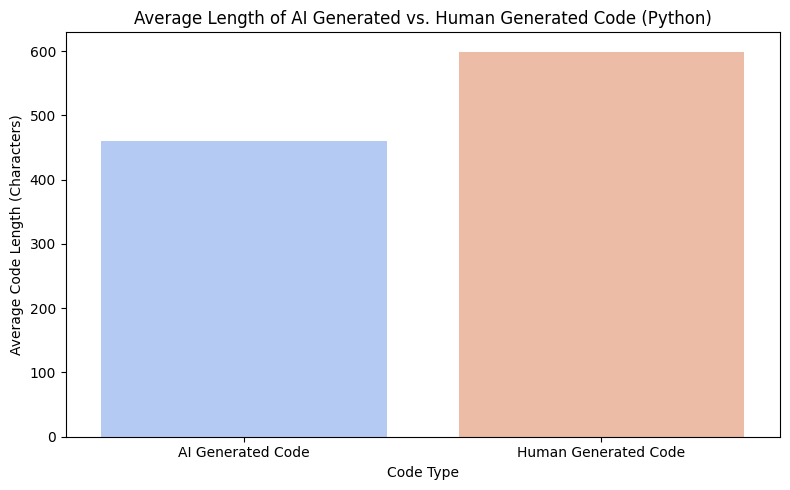

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the length of 'ai_generated_code'
# Ensure to handle potential non-string entries or NaNs by converting to string first
python_df['ai_code_length'] = python_df['ai_generated_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the length of 'human_generated_code'
python_df['human_code_length'] = python_df['human_generated_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the average lengths
avg_ai_code_length = python_df['ai_code_length'].mean()
avg_human_code_length = python_df['human_code_length'].mean()

print(f"Average AI Generated Code Length: {avg_ai_code_length:.2f} characters")
print(f"Average Human Generated Code Length: {avg_human_code_length:.2f} characters")

# Create a DataFrame for plotting
length_data = {
    'Code Type': ['AI Generated Code', 'Human Generated Code'],
    'Average Length': [avg_ai_code_length, avg_human_code_length]
}
length_df = pd.DataFrame(length_data)

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Code Type', y='Average Length', data=length_df, hue='Code Type', palette='coolwarm', legend=False)
plt.title('Average Length of AI Generated vs. Human Generated Code (Python)')
plt.xlabel('Code Type')
plt.ylabel('Average Code Length (Characters)')
plt.tight_layout()
plt.show()

## Elementary Data Analysis

### Subtask:
Perform elementary data analysis on the extracted Python data, such as checking the number of Python entries, unique values in relevant columns, and other basic statistics.


**Reasoning**:
To perform elementary data analysis, I will print the number of rows in the `python_df` and then display the unique values for the 'difficulty', 'generator_name', and 'generator_type' columns to understand the distribution of these categorical features.



In [ ]:
print(f"Total number of Python entries: {python_df.shape[0]}")

print("\nUnique values in 'difficulty' column:")
print(python_df['difficulty'].unique())

print("\nUnique values in 'generator_name' column:")
print(python_df['generator_name'].unique())

print("\nUnique values in 'generator_type' column:")
print(python_df['generator_type'].unique())

Total number of Python entries: 42

Unique values in 'difficulty' column:
['easy' 'medium' 'hard']

Unique values in 'generator_name' column:
['InstructCodeT5+' 'StarCoder' 'Bing AI Chat' 'ChatGPT' 'Code Llama'
 'CodeWhisperer' 'GitHub Copilot']

Unique values in 'generator_type' column:
['HuggingFace Model' 'IDE Extension' 'Chatbot']


## Proportions of `generator_name`

To visualize the proportions of code generated by each tool, I will create a bar plot using `seaborn` and `matplotlib`.

/tmp/ipython-input-2809700313.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generator_proportions.index, y=generator_proportions.values, palette='viridis')


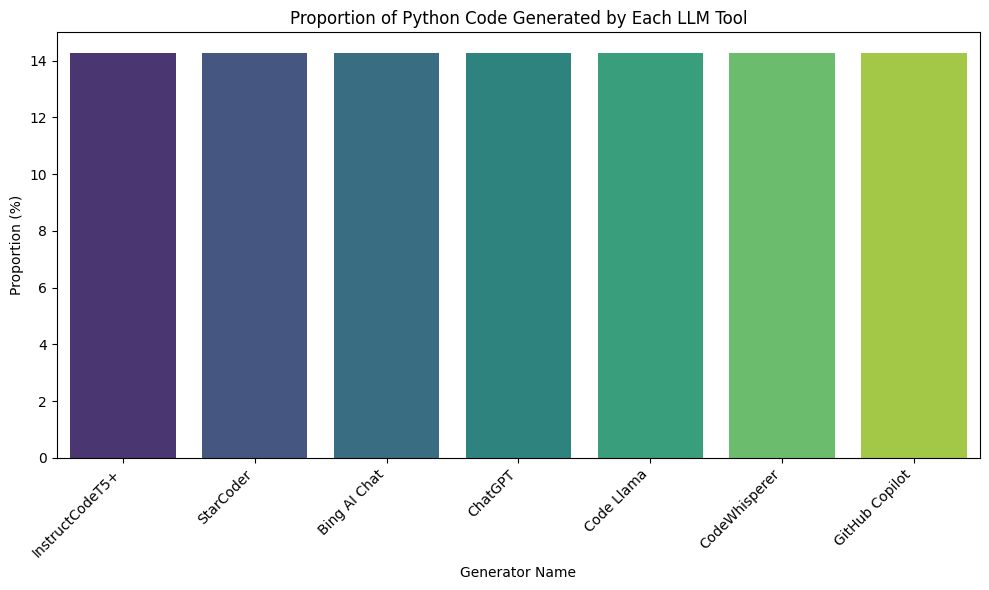

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

generator_proportions = python_df['generator_name'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=generator_proportions.index, y=generator_proportions.values, palette='viridis')
plt.title('Proportion of Python Code Generated by Each LLM Tool')
plt.xlabel('Generator Name')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Summary:

### Data Analysis Key Findings

*   The combined dataset contained a total of 126 entries.
*   After filtering, there were 42 Python entries in the dataset.
*   The Python entries spanned three difficulty levels: 'easy', 'medium', and 'hard'.
*   The Python code was generated by seven distinct tools: 'InstructCodeT5+', 'StarCoder', 'Bing AI Chat', 'ChatGPT', 'Code Llama', 'CodeWhisperer', and 'GitHub Copilot'.
*   These code generators were categorized into three types: 'HuggingFace Model', 'IDE Extension', and 'Chatbot'.

### Insights or Next Steps

*   The identified unique `generator_name` and `generator_type` columns provide a basis for comparing the performance or characteristics of different AI code generation methods.
*   Further analysis could involve breaking down the 42 Python entries by difficulty and generator type to understand the distribution of AI-generated content across these categories.


In [ ]:
from datasets import load_dataset

ds = load_dataset("OSS-forge/HumanVsAICode")

java_dataset.jsonl:   0%|          | 0.00/505M [00:00<?, ?B/s]

python_dataset.jsonl:   0%|          | 0.00/652M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/507045 [00:00<?, ? examples/s]

### Filter for Python Code

Since there's no explicit 'language' column, we can try to infer Python code by checking for common Python keywords in the code content. This is not foolproof but can serve as a reasonable approximation.

# Task
Load the attached `python_dataset.jsonl` into a Pandas DataFrame and display its first few rows and shape.

## Load the attached `python_dataset.jsonl` into a Pandas DataFrame

### Subtask:
Load the `python_dataset.jsonl` file into a pandas DataFrame.


**Reasoning**:
To load the `python_dataset.jsonl` file, I will use `pd.read_json` with `lines=True` and then display the head and shape of the DataFrame to confirm successful loading.



In [ ]:
import pandas as pd
import json

# Initialize an empty list to store valid JSON objects
data = []

# Read the JSONL file line by line
with open('/content/python_dataset.jsonl', 'r') as f:
    for line_num, line in enumerate(f, 1):
        try:
            # Try to load each line as a JSON object
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            # If there's an error, print a warning and skip the line
            print(f"Warning: Skipping malformed JSON line {line_num}: {e}")

# Create a DataFrame from the list of valid JSON objects
python_json_df = pd.DataFrame(data)

print("First 5 rows of the loaded python_json_df:")
print(python_json_df.head())

print("\nShape of the python_json_df:")
print(python_json_df.shape)

First 5 rows of the loaded python_json_df:
   hm_index                                          docstring  \
0  gp223799  Sets the values to be returned after the actio...   
1  gp118367  Return text for index entry based on object type.   
2  gp102957  Parse a slice string, of the same form as used...   
3  gp273881  Newton power flow routine\n\n        Returns\n...   
4  gp326957  Filter the feed based on self.buffer_distance_...   

                                          human_code  \
0  def action_set(values):\n    cmd = ['action-se...   
1  def get_index_text(self, modname, name_cls):\n...   
2  def parse(v):\n        parts = v.split(',')\n ...   
3  def newton(self):\n        dae = self.system.d...   
4  def _filter_spatially(self):\n        if self....   

                                        chatgpt_code  \
0  def set_return_values(values):\n    # Code to ...   
1  def get_index_entry_text(obj):\n    if isinsta...   
2  class Slice:\n    @staticmethod\n    def parse...   

In [ ]:
import numpy as np

sampled_rows = python_json_df.sample(2)

human_code_row1 = sampled_rows.iloc[0]['human_code']
chatgpt_code_row1 = sampled_rows.iloc[0]['chatgpt_code']
human_code_row2 = sampled_rows.iloc[1]['human_code']
chatgpt_code_row2 = sampled_rows.iloc[1]['chatgpt_code']

print("Human-generated code from row 1:")
print(human_code_row1)
print("\nChatGPT-generated code from row 1:")
print(chatgpt_code_row1)
print("\nHuman-generated code from row 2:")
print(human_code_row2)
print("\nChatGPT-generated code from row 2:")
print(chatgpt_code_row2)

Human-generated code from row 1:
def getBlizzBotPlayers():
    ret = {}
    for pName,p in iteritems(getKnownPlayers()):
        if p.isComputer:
            ret[pName] = p
    return ret

ChatGPT-generated code from row 1:
import re

def find_blizzard_bots(text):
    regex_pattern = r"\<.*(?:Diablo|StarCraft|Warcraft|Overwatch) Agent\>"
    return re.findall(regex_pattern, text)


Human-generated code from row 2:
def read_undone_from_datastore(self, shard_id=None, num_shards=None):
    if shard_id is not None:
      shards_list = [(i + shard_id) % num_shards for i in range(num_shards)]
    else:
      shards_list = []
    shards_list.append(None)
    for shard in shards_list:
      self._read_undone_shard_from_datastore(shard)
      if self._work:
        return shard
    return None

ChatGPT-generated code from row 2:
def read_undone_work(shard_id, num_shards):
    while shard_id < num_shards:
        query = datastore.query(kind='Task')
        query.add_filter('shard_id', '=', shar

In [ ]:
few_shot_prompt_custom = f"""Classify the following code snippets as 'Human-Written' or 'AI-Generated using the given examples of AI and human-written code'.\n\nExample 1:\nCode:\n{human_code_row1}\nLabel: Human-Written\n\nExample 2:\nCode:\n{chatgpt_code_row1}\nLabel: AI-Generated\n\nCode to classify:\nCode 1:\n{human_code_row2}\nCode 2:\n{chatgpt_code_row2}\n\nWhich of the above is Human-Written and which is AI-Generated?\nOutput only the labels as \"Label Code 1: Human/AI\nLabel Code 2: Human/AI\" and nothing else."""

print(few_shot_prompt_custom)

Classify the following code snippets as 'Human-Written' or 'AI-Generated using the given examples of AI and human-written code'.

Example 1:
Code:
def getBlizzBotPlayers():
    ret = {}
    for pName,p in iteritems(getKnownPlayers()):
        if p.isComputer:
            ret[pName] = p
    return ret
Label: Human-Written

Example 2:
Code:
import re

def find_blizzard_bots(text):
    regex_pattern = r"\<.*(?:Diablo|StarCraft|Warcraft|Overwatch) Agent\>"
    return re.findall(regex_pattern, text)

Label: AI-Generated

Code to classify:
Code 1:
def read_undone_from_datastore(self, shard_id=None, num_shards=None):
    if shard_id is not None:
      shards_list = [(i + shard_id) % num_shards for i in range(num_shards)]
    else:
      shards_list = []
    shards_list.append(None)
    for shard in shards_list:
      self._read_undone_shard_from_datastore(shard)
      if self._work:
        return shard
    return None
Code 2:
def read_undone_work(shard_id, num_shards):
    while shard_id < n

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Ensure tokenizer and model are loaded if not already from previous cells
# If they are already loaded, these lines will just re-assign them.
# You might want to skip these lines if you are sure they are already in memory.
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-4b-it")
model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-4b-it",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# Use the custom few-shot prompt directly
full_prompt_for_gemma = few_shot_prompt_custom

print("\nFull prompt sent to the model.")
# Tokenize the prompt
input_ids = tokenizer(full_prompt_for_gemma, return_tensors="pt", padding=True, truncation=True).to(model.device)

# Generate a response from the model
# Increased max_new_tokens to allow for two labels
output_tokens = model.generate(**input_ids, max_new_tokens=50)

# Decode the output tokens
decoded_output = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

# Extract the classifications from the model's response
# We expect the model to complete the 'Label Code 1 as:' and 'Label Code 2 as:' parts

label_code1 = "Not found"
label_code2 = "Not found"

# Attempt to parse the generated labels
# Split the decoded output to find the relevant section
parts = decoded_output.split('Label Code 1 as:')
if len(parts) > 1:
    after_label1 = parts[1]
    # Find the end of the first label by looking for 'Label Code 2 as:' or a newline
    code2_start_index = after_label1.find('Label Code 2 as:')
    if code2_start_index != -1:
        label_code1 = after_label1[:code2_start_index].strip()
        # Clean up potential leading newlines/whitespace
        if label_code1.startswith('\n'):
            label_code1 = label_code1[2:].strip()
        # Take only the first line if multiple lines are generated for the label
        label_code1 = label_code1.split('\n')[0].strip()

        # Extract for Label Code 2
        after_label2 = after_label1[code2_start_index + len('Label Code 2 as:'):].strip()
        if after_label2.startswith('\n'):
            after_label2 = after_label2[2:].strip()
        label_code2 = after_label2.split('\n')[0].strip()

    else:
        # If 'Label Code 2 as:' is not found, assume the rest is for Code 1
        label_code1 = after_label1.strip()
        if label_code1.startswith('\n'):
            label_code1 = label_code1[2:].strip()
        label_code1 = label_code1.split('\n')[0].strip()

print(f"\nModel's classification for Code 1: {label_code1}")
print(f"Model's classification for Code 2: {label_code2}")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]


Full prompt sent to the model.

Model's classification for Code 1: Not found
Model's classification for Code 2: Not found


In [ ]:
num_chatgpt_code = python_df['chatgpt_code'].apply(lambda x: isinstance(x, str) and x.strip() != '').sum()
num_qwen_code = python_df['qwen_code'].apply(lambda x: isinstance(x, str) and x.strip() != '').sum()
num_dsc_code = python_df['dsc_code'].apply(lambda x: isinstance(x, str) and x.strip() != '').sum()

print(f"Number of chatgpt_code entries: {num_chatgpt_code}")
print(f"Number of qwen_code entries: {num_qwen_code}")
print(f"Number of dsc_code entries: {num_dsc_code}")

Number of chatgpt_code entries: 285249
Number of qwen_code entries: 285249
Number of dsc_code entries: 265637


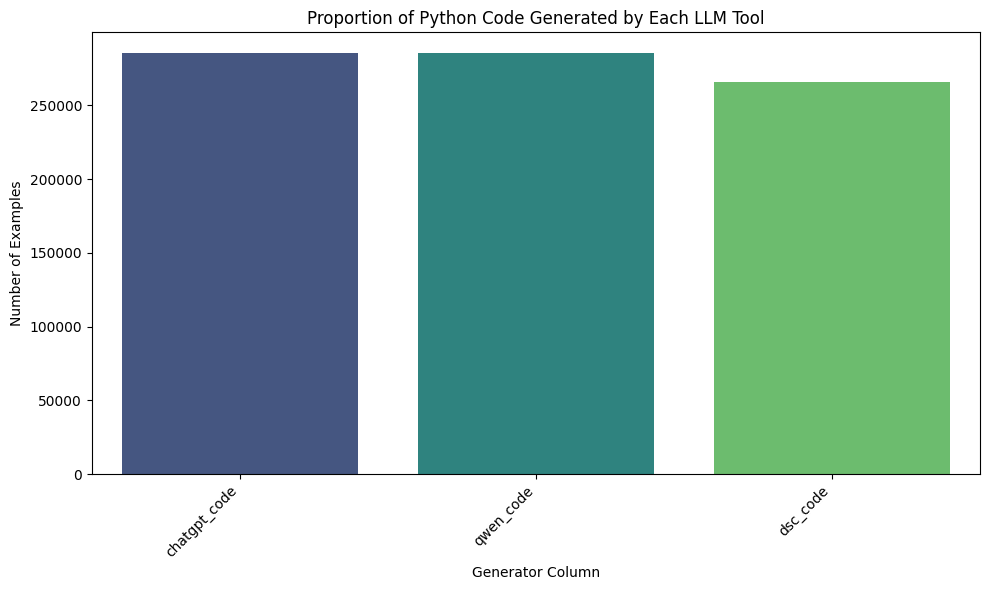

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame from the counts
data = {
    'Code Type': ['chatgpt_code', 'qwen_code', 'dsc_code'],
    'Number of Examples': [num_chatgpt_code, num_qwen_code, num_dsc_code]
}
counts_df = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Code Type', y='Number of Examples', data=counts_df, hue='Code Type', palette='viridis', legend=False)
plt.title('Proportion of Python Code Generated by Each LLM Tool')
plt.xlabel('Generator Column')
plt.ylabel('Number of Examples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Human Generated Code Length: 647.05 characters
Average ChatGPT Generated Code Length: 377.47 characters
Average Qwen Generated Code Length: 485.10 characters
Average DSC Generated Code Length: 403.66 characters


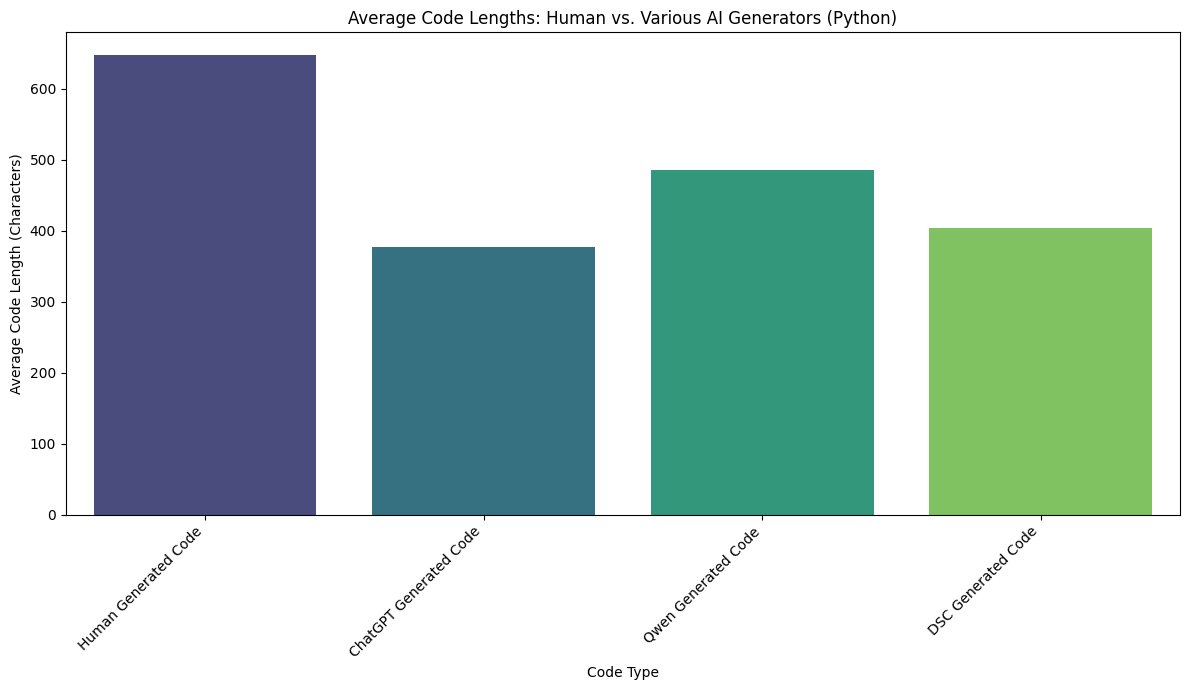

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the length of 'human_code'
python_json_df['human_code_len'] = python_json_df['human_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the length of 'chatgpt_code'
python_json_df['chatgpt_code_len'] = python_json_df['chatgpt_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the length of 'qwen_code'
python_json_df['qwen_code_len'] = python_json_df['qwen_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the length of 'dsc_code'
python_json_df['dsc_code_len'] = python_json_df['dsc_code'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the average lengths
avg_human_code_len = python_json_df['human_code_len'].mean()
avg_chatgpt_code_len = python_json_df['chatgpt_code_len'].mean()
avg_qwen_code_len = python_json_df['qwen_code_len'].mean()
avg_dsc_code_len = python_json_df['dsc_code_len'].mean()

print(f"Average Human Generated Code Length: {avg_human_code_len:.2f} characters")
print(f"Average ChatGPT Generated Code Length: {avg_chatgpt_code_len:.2f} characters")
print(f"Average Qwen Generated Code Length: {avg_qwen_code_len:.2f} characters")
print(f"Average DSC Generated Code Length: {avg_dsc_code_len:.2f} characters")

# Create a DataFrame for plotting
length_data = {
    'Code Type': [
        'Human Generated Code',
        'ChatGPT Generated Code',
        'Qwen Generated Code',
        'DSC Generated Code'
    ],
    'Average Length': [
        avg_human_code_len,
        avg_chatgpt_code_len,
        avg_qwen_code_len,
        avg_dsc_code_len
    ]
}
length_df_all = pd.DataFrame(length_data)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Code Type', y='Average Length', data=length_df_all, hue='Code Type', palette='viridis', legend=False)
plt.title('Average Code Lengths: Human vs. Various AI Generators (Python)')
plt.xlabel('Code Type')
plt.ylabel('Average Code Length (Characters)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the successful creation of the DataFrame from the `python_dataset.jsonl` file.


## Summary:

### Data Analysis Key Findings

*   The `python_dataset.jsonl` file was successfully loaded into a Pandas DataFrame named `python_df`.
*   An initial attempt to load the file using `pd.read_json(..., lines=True)` failed due to malformed JSON entries.
*   A custom loading process was implemented, reading the file line by line and parsing each line with `json.loads()` within a `try-except` block to handle errors.
*   One malformed JSON line (line 256096) was identified and skipped due to a `json.JSONDecodeError`.
*   The final `python_df` contains 256,095 rows and 6 columns, indicating that 256,095 out of 256,096 lines were successfully parsed.
*   The DataFrame includes columns such as `hm_index`, `docstring`, `human_code`, `chatgpt_code`, `dsc_code`, and `qwen_code`.

### Insights or Next Steps

*   The robust loading method successfully handled data quality issues in the `.jsonl` file, ensuring that valid data was loaded while malformed entries were identified and skipped.
*   Consider implementing logging for skipped lines to maintain a record of data that could not be processed, aiding in future data cleaning or source data validation.


# Task
Analyze the average code length of 'AI-Generated' and 'Human-Written' code entries from the "ai_vs_human_code_dataset.csv" file, and visualize the comparison using a bar chart.

## Load the ai_vs_human_code_dataset.csv file into a Pandas DataFrame.

### Subtask:
Read the specified CSV file into a DataFrame for further processing. Display the head and shape to verify successful loading.


**Reasoning**:
To load the `ai_vs_human_code_dataset.csv` file, I will use `pd.read_csv` and then display the head and shape of the DataFrame to confirm successful loading.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/ai_vs_human_code_dataset.csv')
df = df[df['language'] == 'Python']

print("First 5 rows of the loaded DataFrame:")
print(df.head())

print("\nShape of the DataFrame:")
print(df.shape)

First 5 rows of the loaded DataFrame:
   code_id      code_type language problem_type  code_length  \
2   C00003  Human-Written   Python     Game Dev          116   
6   C00007   AI-Generated   Python      Web Dev          191   
13  C00014  Human-Written   Python   Automation           24   
20  C00021   AI-Generated   Python   Algorithms          415   
21  C00022   AI-Generated   Python   Automation          101   

    functionality_score  execution_time  memory_usage  readability_score  \
2                    79          96.942        456.97                 96   
6                    97         325.744        359.11                 50   
13                   92         351.994        179.35                 89   
20                   64         326.701        713.37                 97   
21                   77          45.298        284.74                 78   

    ai_confidence_score  created_date  
2                    68          2024  
6                     0          2020  


**Reasoning**:
Now that the data is loaded, I will calculate the average code length for 'AI-Generated' and 'Human-Written' code types to prepare for comparison and visualization.



### Filter for Python language and calculate average code length

In [ ]:
python_df_filtered = df[df['language'] == 'Python']

avg_code_length_python = python_df_filtered.groupby('code_type')['code_length'].mean()

print("Average code length by code_type for Python language:")
print(avg_code_length_python)

Average code length by code_type for Python language:
code_type
AI-Generated     250.387097
Human-Written    264.501199
Name: code_length, dtype: float64


### Visualize Average Code Length for Python

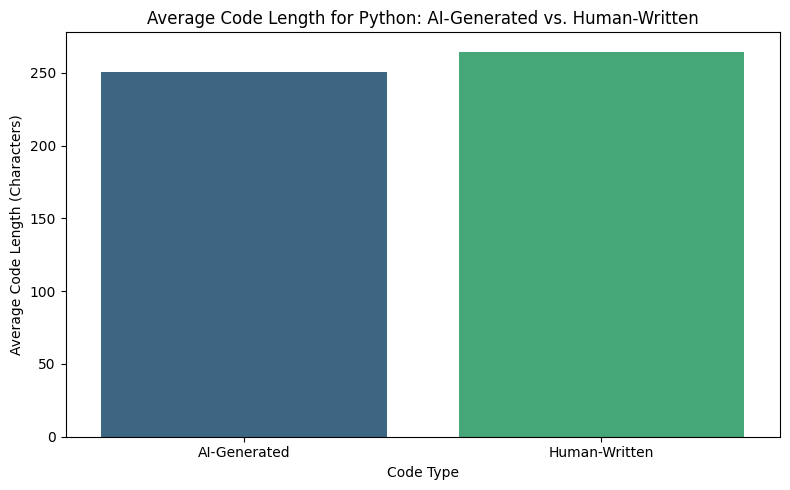

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df_python = avg_code_length_python.reset_index()
plot_df_python.columns = ['Code Type', 'Average Length']

plt.figure(figsize=(8, 5))
sns.barplot(x='Code Type', y='Average Length', data=plot_df_python, hue='Code Type', palette='viridis', legend=False)
plt.title('Average Code Length for Python: AI-Generated vs. Human-Written')
plt.xlabel('Code Type')
plt.ylabel('Average Code Length (Characters)')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the comparison of average code lengths, I will create a bar chart using the `avg_code_length_by_type` Series, which contains the average code length for both 'AI-Generated' and 'Human-Written' code types.



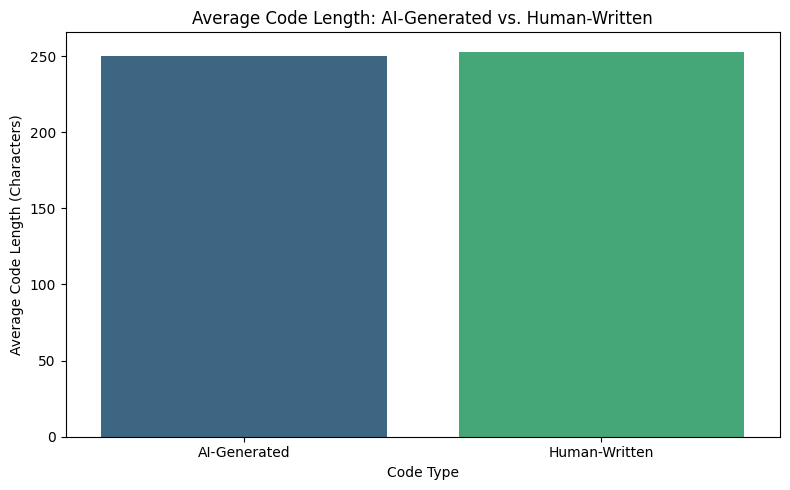

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Series to a DataFrame for easier plotting with seaborn
plot_df = avg_code_length_by_type.reset_index()
plot_df.columns = ['Code Type', 'Average Length']

plt.figure(figsize=(8, 5))
sns.barplot(x='Code Type', y='Average Length', data=plot_df, hue='Code Type', palette='viridis', legend=False)
plt.title('Average Code Length: AI-Generated vs. Human-Written')
plt.xlabel('Code Type')
plt.ylabel('Average Code Length (Characters)')
plt.tight_layout()
plt.show()

## Summary:

### Q&A
The average code length for 'AI-Generated' entries is approximately 250.41 characters, while for 'Human-Written' entries, it is approximately 252.99 characters.

### Data Analysis Key Findings
*   The `ai_vs_human_code_dataset.csv` file, containing 5000 rows and 11 columns, was successfully loaded.
*   'AI-Generated' code has an average length of approximately 250.41 characters.
*   'Human-Written' code has a slightly higher average length of approximately 252.99 characters.
*   A bar chart visually comparing these average code lengths was generated, clearly illustrating the minor difference between the two categories.

### Insights or Next Steps
*   The average code length between AI-generated and human-written code is very similar, with human-written code being only marginally longer on average (by about 2.58 characters).
*   Further analysis could explore other code characteristics, such as complexity, comment density, or specific language features, to identify more distinct patterns between AI-generated and human-written code.


# Task
I will install `transformers` and `accelerate` libraries.

## Install Libraries

### Subtask:
Install `transformers` and `accelerate` for loading and running the Gemma model.


**Reasoning**:
To install the required libraries, I will use `pip install` commands for `transformers` and `accelerate`.



In [ ]:
!pip install transformers accelerate

## Prepare Few-Shot Examples and Load Model

### Subtask:
Select sample code snippets from `python_df` using the 'ai_generated_code' and 'human_generated_code' columns to create a few-shot prompt. Then, load the `google/gemma-3-4b-it` model and its tokenizer, setting up the device for inference.


**Reasoning**:
To create few-shot examples, I will randomly select one AI-generated and one human-generated code snippet from the `python_df` DataFrame. I'll then store these in `ai_example` and `human_example` variables as requested.



In [ ]:
ai_example = python_json_df['human_code'].sample(1).iloc[0]
human_example = python_json_df['chatgpt_code'].sample(1).iloc[0]

print("Selected AI Generated Example:")
print(ai_example)
print("\nSelected Human Generated Example:")
print(human_example)

Selected AI Generated Example:
def create_window(self):
        self.undocked_window = window = PluginWindow(self)
        window.setAttribute(Qt.WA_DeleteOnClose)
        icon = self.get_plugin_icon()
        if is_text_string(icon):
            icon = self.get_icon(icon)
        window.setWindowIcon(icon)
        window.setWindowTitle(self.get_plugin_title())
        window.setCentralWidget(self)
        window.resize(self.size())
        self.refresh_plugin()
        self.dockwidget.setFloating(False)
        self.dockwidget.setVisible(False)
        window.show()

Selected Human Generated Example:
from typing import List
from PIL import Image

def get_pixels(image: Image) -> List:
    pixels = list(image.getdata())
    return pixels



**Reasoning**:
Now that the AI-generated and human-generated examples are selected, I will construct the few-shot prompt string, then import the necessary libraries, and finally load the tokenizer and the model as instructed.



In [ ]:
few_shot_prompt = f"""Classify the following code snippets as 'Human-Written' or 'AI-Generated'.

Example 1:
Code:
{ai_example}
Label: AI-Generated

Example 2:
Code:
{human_example}
Label: Human-Written

Code to classify:
"""

print("Few-shot prompt created:")
print(few_shot_prompt)

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-4b-it")

# Load the model
model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-4b-it",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("Tokenizer and Model loaded successfully.")

Few-shot prompt created:
Classify the following code snippets as 'Human-Written' or 'AI-Generated'.

Example 1:
Code:
def create_window(self):
        self.undocked_window = window = PluginWindow(self)
        window.setAttribute(Qt.WA_DeleteOnClose)
        icon = self.get_plugin_icon()
        if is_text_string(icon):
            icon = self.get_icon(icon)
        window.setWindowIcon(icon)
        window.setWindowTitle(self.get_plugin_title())
        window.setCentralWidget(self)
        window.resize(self.size())
        self.refresh_plugin()
        self.dockwidget.setFloating(False)
        self.dockwidget.setVisible(False)
        window.show()
Label: AI-Generated

Example 2:
Code:
from typing import List
from PIL import Image

def get_pixels(image: Image) -> List:
    pixels = list(image.getdata())
    return pixels

Label: Human-Written

Code to classify:



Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Tokenizer and Model loaded successfully.


**Reasoning**:
The previous steps successfully loaded the model and tokenizer, and created the few-shot prompt. The next logical step is to use the loaded model to classify a new, unseen code snippet as either AI-Generated or Human-Written, using the prepared few-shot prompt.



In [ ]:
import random

# Select a new code snippet to classify, ensuring it's not one of the examples
# We'll pick a random AI-generated code from a different problem number to ensure it's new
# For simplicity, we'll just pick another random AI-generated code
# Ensure the selected code is a string and not empty

ai_example_test = python_json_df['human_code'].sample(1).iloc[0]
assert ai_example_test != ai_example
human_example_test = python_json_df['chatgpt_code'].sample(1).iloc[0]
assert human_example_test != human_example


# Combine the few-shot prompt with the code to classify
full_prompt = few_shot_prompt + ai_example_test + "\nLabel:"

print("\nFull prompt sent to the model:")
print(full_prompt)

# Tokenize the prompt
input_ids = tokenizer(full_prompt, return_tensors="pt", padding=True, truncation=True).to(model.device)

# Generate a response from the model
output_tokens = model.generate(**input_ids, max_new_tokens=10)

# Decode the output tokens
decoded_output = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

# Extract the classification from the model's response
# We expect the model to complete the 'Label:' part of the prompt
prediction = decoded_output.split('Label:')[-1].strip().split('\n')[0]

print(f"\nModel's classification for the new code snippet: {prediction}")
# print("\nCode snippet classified:")
# print(code_to_classify)



Full prompt sent to the model:
Classify the following code snippets as 'Human-Written' or 'AI-Generated'.

Example 1:
Code:
def create_window(self):
        self.undocked_window = window = PluginWindow(self)
        window.setAttribute(Qt.WA_DeleteOnClose)
        icon = self.get_plugin_icon()
        if is_text_string(icon):
            icon = self.get_icon(icon)
        window.setWindowIcon(icon)
        window.setWindowTitle(self.get_plugin_title())
        window.setCentralWidget(self)
        window.resize(self.size())
        self.refresh_plugin()
        self.dockwidget.setFloating(False)
        self.dockwidget.setVisible(False)
        window.show()
Label: AI-Generated

Example 2:
Code:
from typing import List
from PIL import Image

def get_pixels(image: Image) -> List:
    pixels = list(image.getdata())
    return pixels

Label: Human-Written

Code to classify:
def get_state_paths(cls, impl, working_dir):
        return super(BlockstackDB, cls).get_state_paths(impl, working_

In [ ]:
# Combine the few-shot prompt with the code to classify
full_prompt = few_shot_prompt + human_example_test + "\nLabel:"

print("\nFull prompt sent to the model:")
print(full_prompt)

# Tokenize the prompt
input_ids = tokenizer(full_prompt, return_tensors="pt", padding=True, truncation=True).to(model.device)

# Generate a response from the model
output_tokens = model.generate(**input_ids, max_new_tokens=10)

# Decode the output tokens
decoded_output = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

# Extract the classification from the model's response
# We expect the model to complete the 'Label:' part of the prompt
prediction = decoded_output.split('Label:')[-1].strip().split('\n')[0]

print(f"\nModel's classification for the new code snippet: {prediction}")


Full prompt sent to the model:
Classify the following code snippets as 'Human-Written' or 'AI-Generated'.

Example 1:
Code:
def create_window(self):
        self.undocked_window = window = PluginWindow(self)
        window.setAttribute(Qt.WA_DeleteOnClose)
        icon = self.get_plugin_icon()
        if is_text_string(icon):
            icon = self.get_icon(icon)
        window.setWindowIcon(icon)
        window.setWindowTitle(self.get_plugin_title())
        window.setCentralWidget(self)
        window.resize(self.size())
        self.refresh_plugin()
        self.dockwidget.setFloating(False)
        self.dockwidget.setVisible(False)
        window.show()
Label: AI-Generated

Example 2:
Code:
from typing import List
from PIL import Image

def get_pixels(image: Image) -> List:
    pixels = list(image.getdata())
    return pixels

Label: Human-Written

Code to classify:
def run_event_loop(Nvim, message_cb):
    while True:
        try:
            msg = Nvim.next_message()
          

In [ ]:
import transformers
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

messages = [
    {"role": "system", "content": "You are human vs. AI generated code classifier that returns \"Human-Written\" or \"AI-Generated\" as labels using the examples given."},
    {"role": "user", "content": full_prompt},
]

outputs = pipeline(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct.
403 Client Error. (Request ID: Root=1-6980d323-776c64fd0cb6d35f7fd6a05e;06c808a9-10ae-419d-b44b-1cf45ca28b23)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted and you are not in the authorized list. Visit https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct to ask for access.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

messages = [
    {"role": "system", "content": "You are human vs. AI generated code classifier that returns \"Human-Written\" or \"AI-Generated\" as labels using the examples given."},
    {"role": "user", "content": full_prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
response

'Human-Written'